# Import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [2]:
data = pd.read_csv('../input/datasets/shivamb/netflix-shows/netflix_titles.csv')
data.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
data.shape

(8807, 12)

In [4]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
data.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
print("Total rows:", data.shape[0])
print("Duplicate rows:", data.duplicated().sum())

Total rows: 8807
Duplicate rows: 0


In [9]:
df = data.copy()

In [10]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [11]:
df.dropna(inplace=True)

In [12]:
df.shape

(5696, 12)

In [13]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [14]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [15]:
df['date_added'] = pd.to_datetime(
    data['date_added'].str.strip(),
    format='%B %d, %Y',
    errors='coerce'
)

df = df.dropna(subset=['date_added'])

df['day_added'] = df['date_added'].dt.day.astype('Int64')
df['year_added'] = df['date_added'].dt.year.astype('Int64')
df['month_added'] = df['date_added'].dt.month.astype('Int64')

In [16]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day_added,year_added,month_added
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,2021,9
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,24,2021,9
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,2021,9
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",24,2021,9
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,24,2021,9


In [17]:
data['type'].value_counts('normalize')

type
Movie      0.696151
TV Show    0.303849
Name: proportion, dtype: float64

In [18]:
data['country'].value_counts()

country
United States                                                      2818
India                                                               972
United Kingdom                                                      419
Japan                                                               245
South Korea                                                         199
                                                                   ... 
Mexico, United States, Spain, Colombia                                1
Canada, Norway                                                        1
Finland, Germany, Belgium                                             1
Argentina, United States, Mexico                                      1
United Kingdom, United States, Germany, Denmark, Belgium, Japan       1
Name: count, Length: 748, dtype: int64

# data visulaization

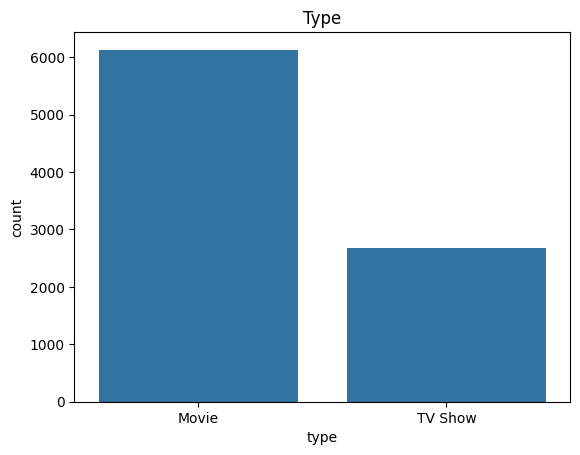

In [19]:
sns.countplot(data, x='type')
plt.title('Type')
plt.show()

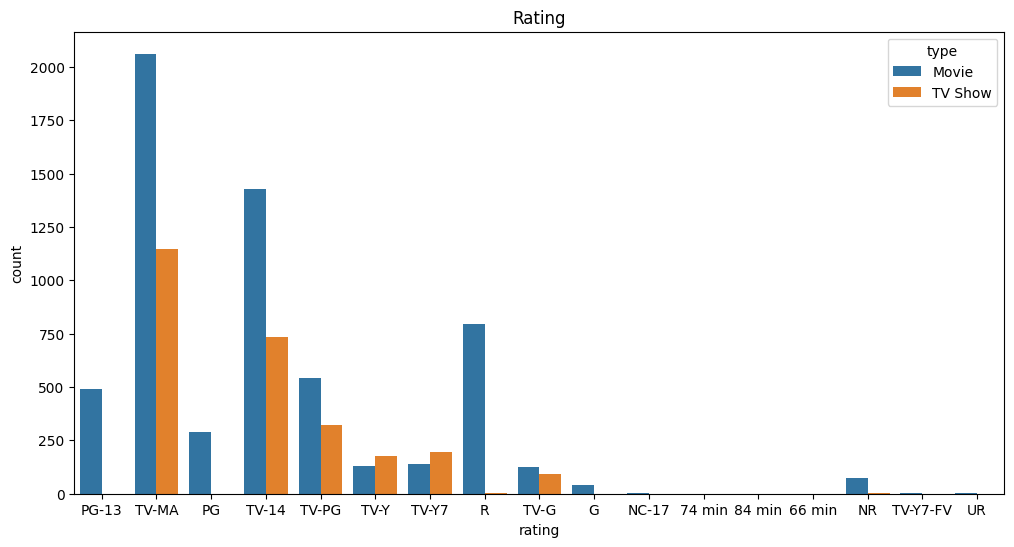

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(data, x='rating', hue='type')
plt.title('Rating')
plt.show()

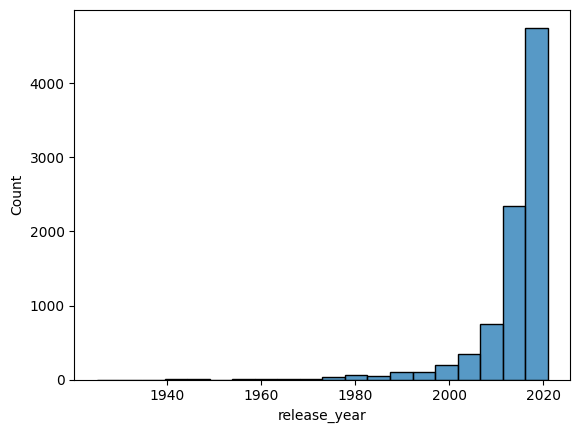

In [21]:
sns.histplot(data, x='release_year', bins=20)
plt.show()

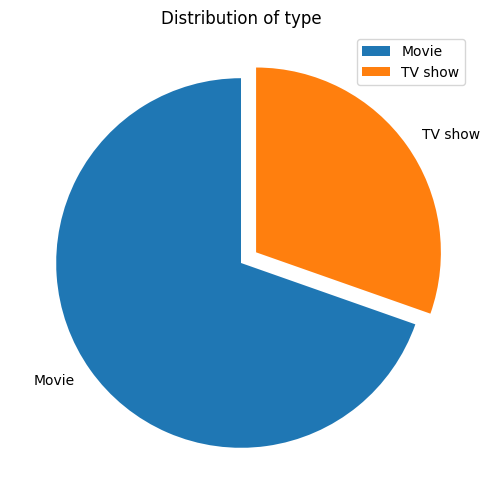

In [22]:
labels = ['Movie', 'TV show']
size = data['type'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(size, labels=labels, startangle=90, explode=[0,0.1])
plt.title('Distribution of type')
plt.legend()
plt.show()

# WordCloud

# Country

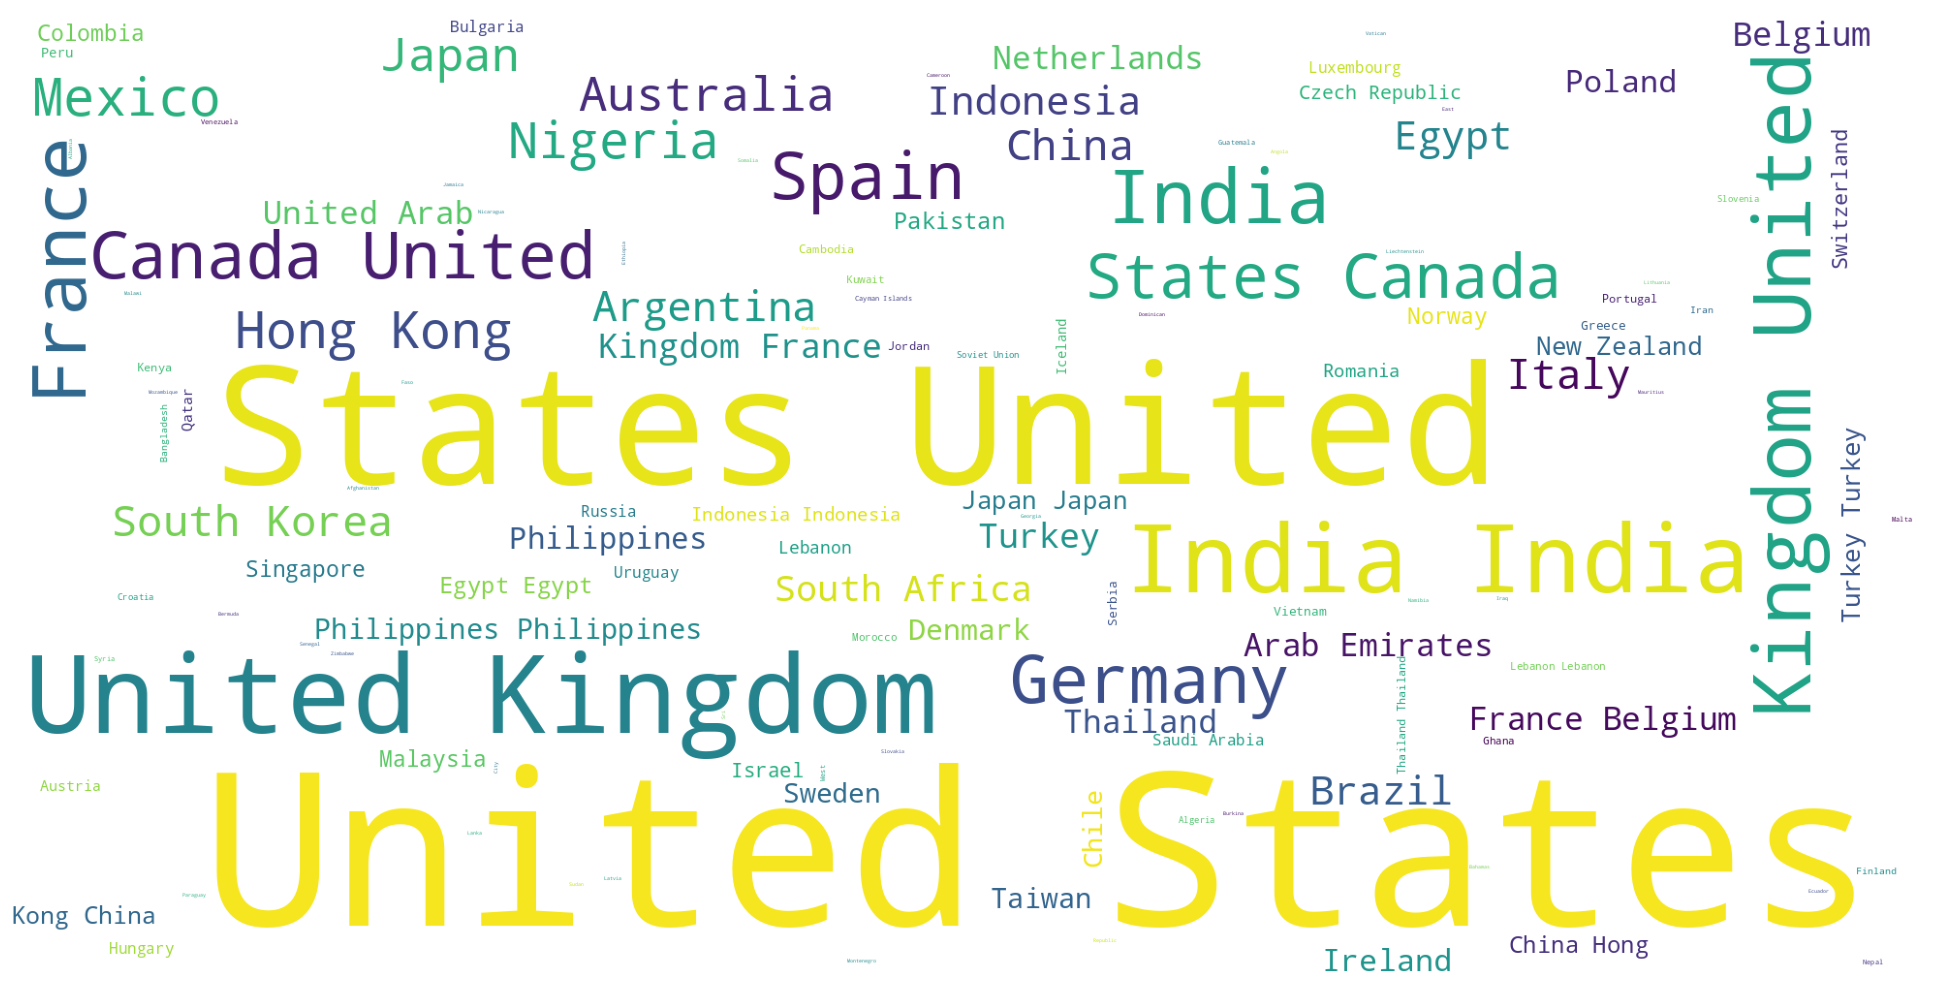

In [23]:
from wordcloud import WordCloud

plt.subplots(figsize=(25,15))
wc = WordCloud(background_color='white', width=2000, height=1000).generate(' '.join(df.country))

plt.imshow(wc)
plt.axis('off')
plt.show()

# Cast

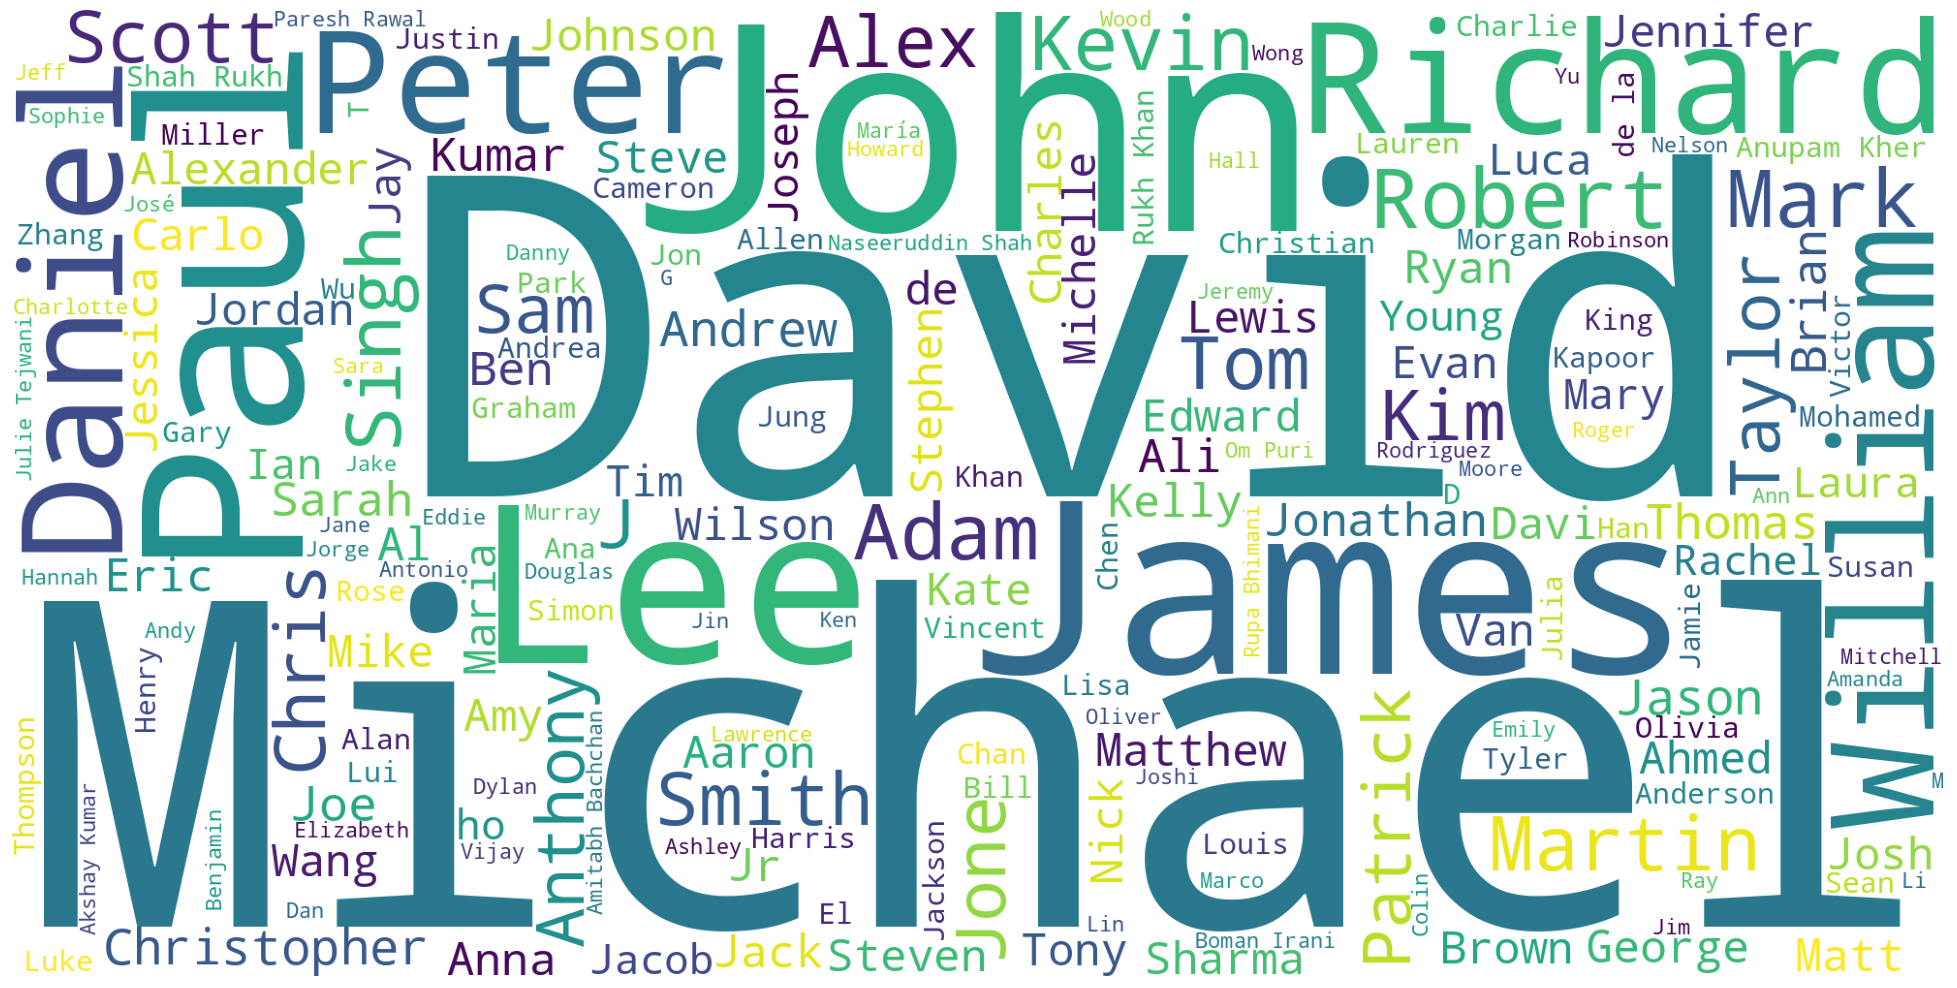

In [24]:
from wordcloud import WordCloud

plt.subplots(figsize=(25,15))
wc = WordCloud(background_color='white', width=2000, height=1000).generate(' '.join(df.cast))

plt.imshow(wc)
plt.axis('off')
plt.show()

# Director

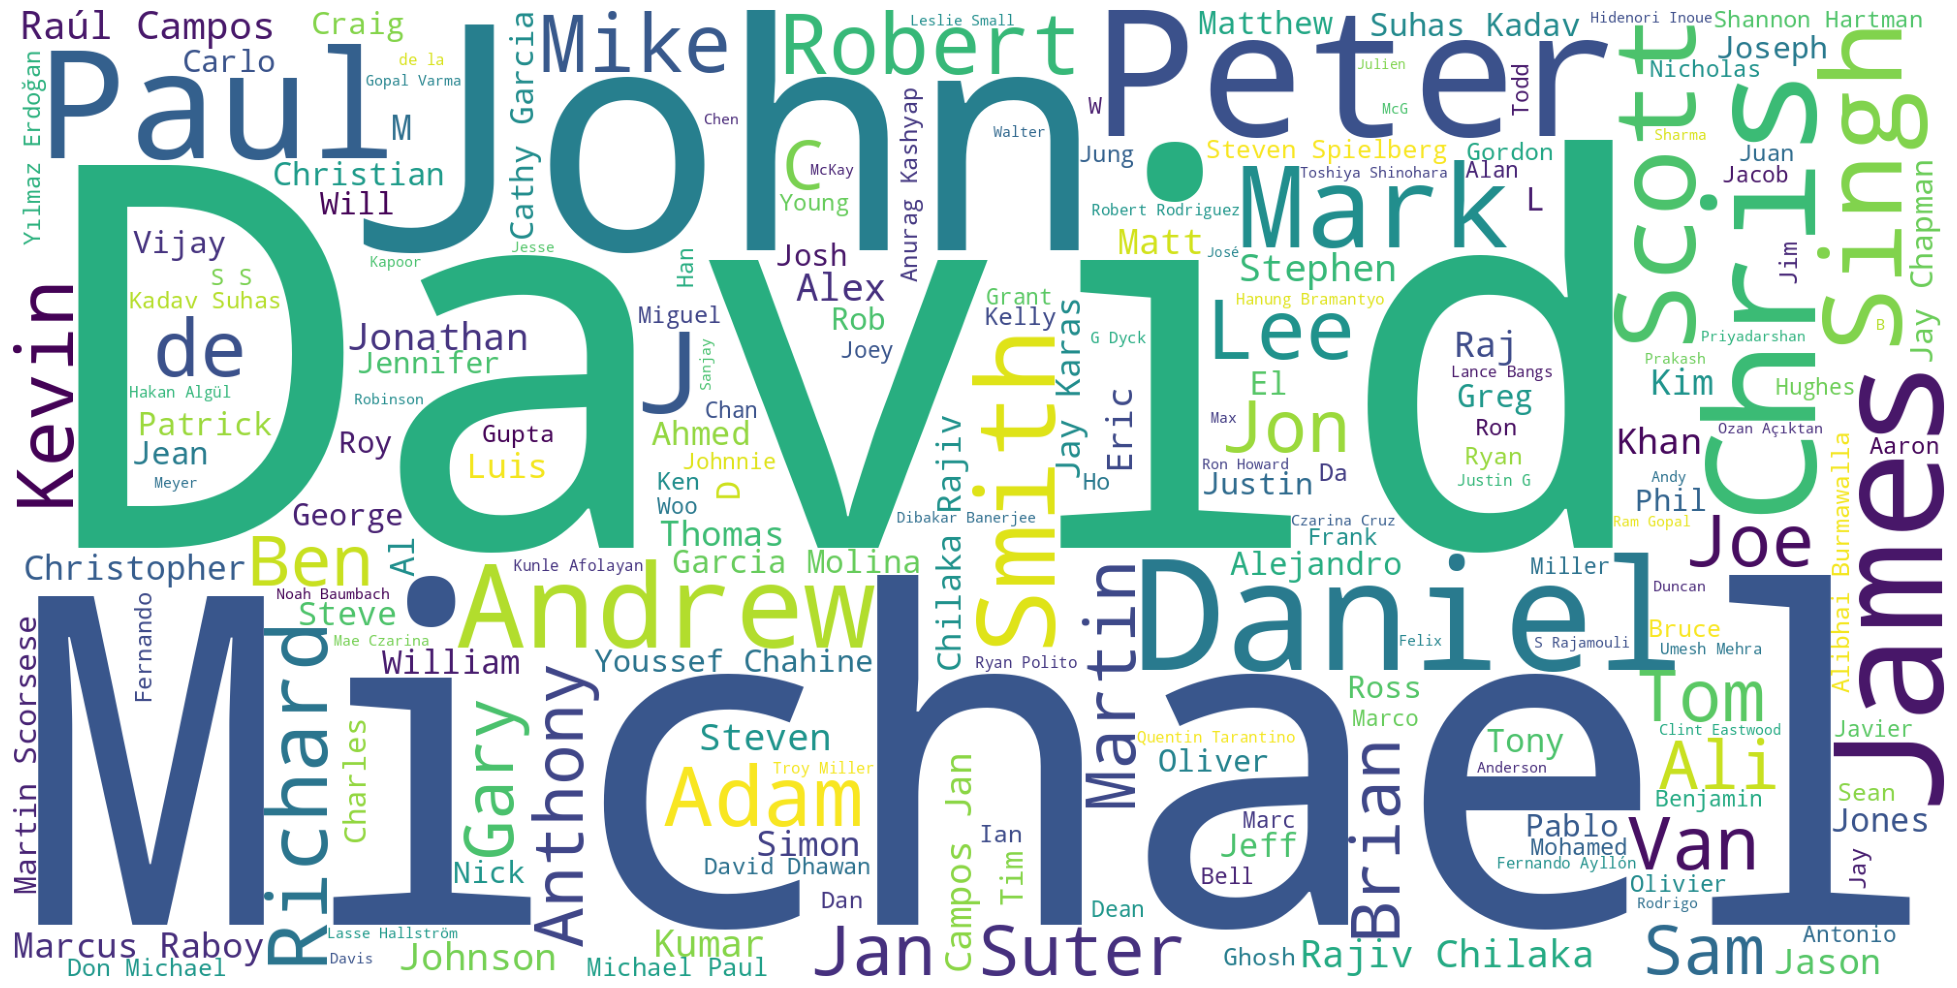

In [25]:
from wordcloud import WordCloud

plt.subplots(figsize=(25,15))
wc = WordCloud(background_color='white', width=2000, height=1000).generate(' '.join(df.director))

plt.imshow(wc)
plt.axis('off')
plt.show()

# Listed in

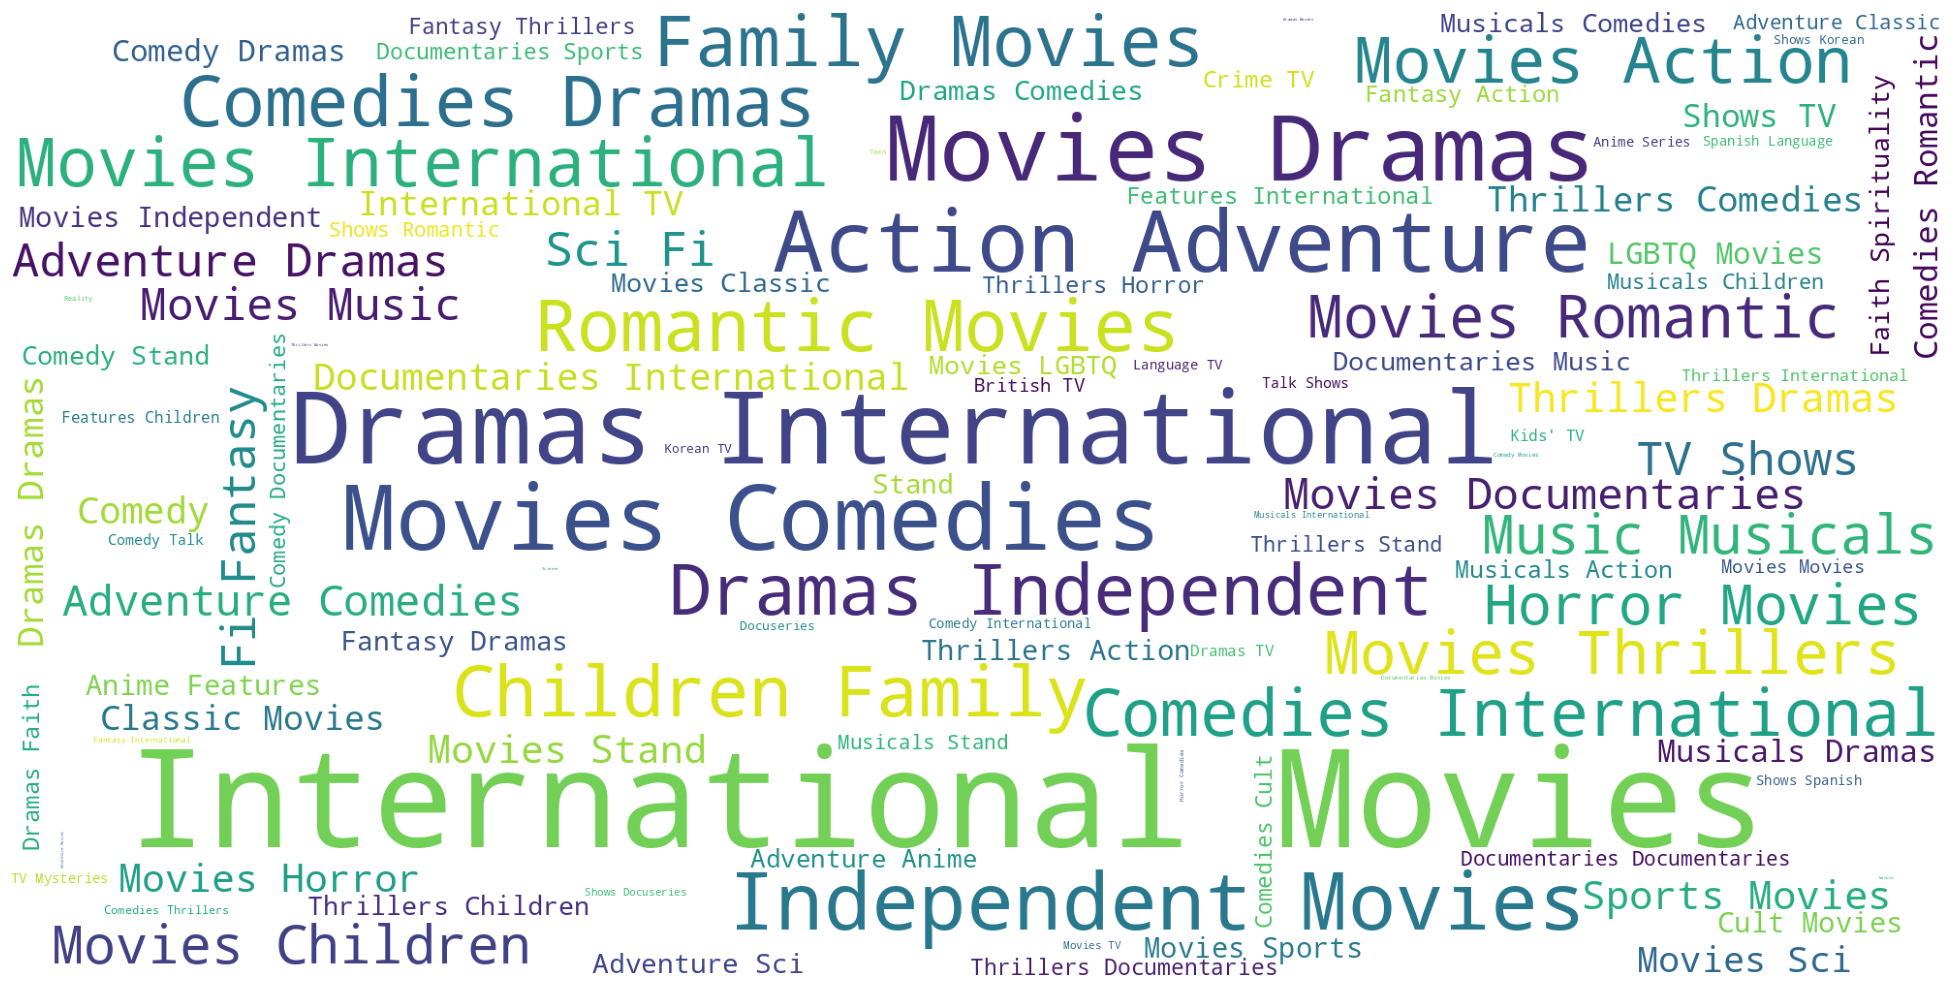

In [26]:
from wordcloud import WordCloud

plt.subplots(figsize=(25,15))
wc = WordCloud(background_color='white', width=2000, height=1000).generate(' '.join(df.listed_in))

plt.imshow(wc)
plt.axis('off')
plt.show()